# Chapter 178 — Linear Layers in Deep Learning

> **Prerequisites:** ch154 (matrix multiplication), ch155 (transpose), ch164 (linear transformations), ch177 (linear algebra for neural networks)
> **You will learn:**
> - How batched computation turns single-sample inference into matrix-matrix multiplication
> - The parameter count and computational cost of a fully connected layer
> - Why weight tying, low-rank approximation, and factored layers reduce cost without sacrificing much accuracy
> - How attention in transformers is a learned weighted combination — a generalized projection
> - How to implement a complete mini-batch training loop using only numpy
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Chapter 177 established that a neural network layer is an affine map: `z = Wx + b`. This chapter goes one level of engineering deeper: how does that single operation scale to *batches* of inputs, to *millions of parameters*, and to the architectural variants (convolutional layers, attention) that dominate modern deep learning?

The answer in every case is the same: **matrix-matrix multiplication, carefully arranged**.

A "linear layer" in any deep learning framework is nothing more than a matrix multiply with a learned weight matrix. The geometry (ch164), the spectral properties (ch177), the gradient mechanics (ch176) — all of those still apply. What changes in this chapter is scale, batching, and the specific structures that practitioners impose on the weight matrix to control cost and inductive bias.

**What problem does this solve?**  
Deep learning models are trained on datasets with millions of examples and weight matrices with millions of parameters. Understanding the linear algebra of batched computation tells you why GPU parallelism works, how memory bandwidth constrains throughput, and why certain architectural choices (factored layers, low-rank adapters) are computationally justified.

**Common misconceptions:**
- "Fully connected layers are the most powerful." — A fully connected layer has the most parameters per unit output, but maximum parameters ≠ maximum useful capacity. Structured weight matrices (convolutional, low-rank) often generalize better by encoding inductive bias.
- "Batching is just a speed trick." — Batching also stabilizes gradient estimates (variance reduction via averaging) and is required for batch normalization to function.
- "Attention is not a linear layer." — The Q, K, V projections in attention are exactly linear layers. The softmax-weighted sum of values is a data-dependent linear combination — a projection matrix whose weights are computed from the data itself.

---

## 2. Intuition & Mental Models

**Batching = stacking column vectors into a matrix.** A single forward pass computes `z = Wx` (matrix-vector). With B inputs stacked as columns `X = [x₁ | x₂ | ... | xB]` (shape n_in × B), the batch forward pass is `Z = WX` (matrix-matrix). One operation processes the whole batch simultaneously — this is exactly what BLAS Level-3 routines (and GPU tensor cores) are built to do efficiently.

**Think of each output neuron as an inner product machine.** Row i of W is a vector `wᵢ ∈ R^{n_in}`. The i-th output is `zᵢ = wᵢᵀx + bᵢ` — the dot product of that row with the input, plus a scalar offset. The layer learns n_out such inner products simultaneously. This is ch131 (dot product) applied n_out times in parallel.

**Low-rank layers = bottleneck compression.** If you replace a weight matrix W ∈ R^{m×n} with the product of two smaller matrices A ∈ R^{m×r} and B ∈ R^{r×n} (r ≪ min(m,n)), the parameter count drops from mn to r(m+n) while the operation rank is bounded by r. This is *(ch173 — SVD)* applied as a compression strategy: keep only the r most important singular directions.

**Attention as a data-dependent projection.** Standard projection: `y = Wx`. Attention: `y = W(x) · x` where W(x) is a matrix whose entries are *functions of the input* (computed via softmax over query-key scores). It is still a linear combination of value vectors — but the coefficients change with every input. Recall from ch168 (projection matrices) that any weighted sum of vectors is a projection; attention makes the weights input-dependent.

---

## 3. Visualization

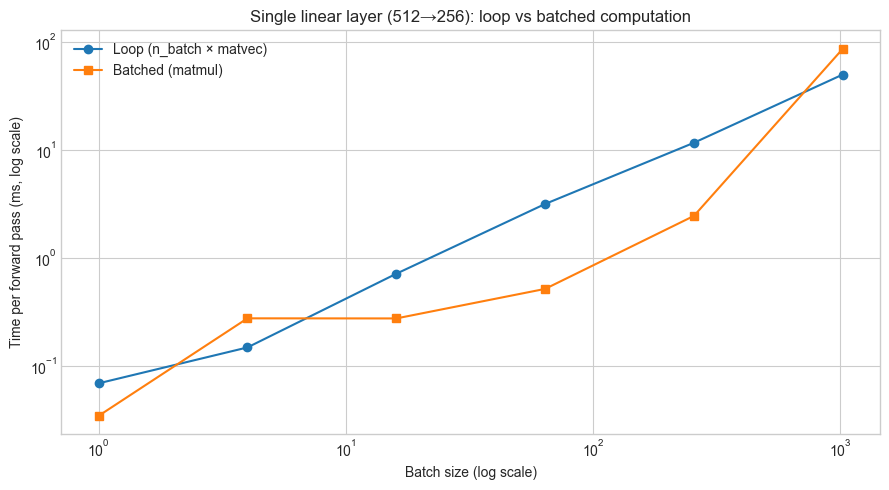

Speedup factors (loop time / batch time):
  B=    1: 2.0x
  B=    4: 0.5x
  B=   16: 2.6x
  B=   64: 6.1x
  B=  256: 4.8x
  B= 1024: 0.6x


In [1]:
# --- Visualization: Single sample vs batch computation ---
# Show that batching turns n_batch matrix-vector products
# into one matrix-matrix product of the same mathematical result.

import numpy as np
import matplotlib.pyplot as plt
import time

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(0)
N_IN = 512
N_OUT = 256
BATCH_SIZES = [1, 4, 16, 64, 256, 1024]

W = np.random.randn(N_OUT, N_IN)

loop_times = []
batch_times = []

for B in BATCH_SIZES:
    X = np.random.randn(N_IN, B)

    # Loop over samples
    t0 = time.perf_counter()
    for _ in range(5):
        Z_loop = np.column_stack([W @ X[:, i] for i in range(B)])
    loop_times.append((time.perf_counter() - t0) / 5)

    # Batched matrix multiply
    t0 = time.perf_counter()
    for _ in range(5):
        Z_batch = W @ X
    batch_times.append((time.perf_counter() - t0) / 5)

    # Verify equivalence
    assert np.allclose(Z_loop, Z_batch), "Batch and loop results must match"

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(BATCH_SIZES, [t * 1000 for t in loop_times], 'o-', label='Loop (n_batch × matvec)')
ax.loglog(BATCH_SIZES, [t * 1000 for t in batch_times], 's-', label='Batched (matmul)')
ax.set_xlabel('Batch size (log scale)')
ax.set_ylabel('Time per forward pass (ms, log scale)')
ax.set_title(f'Single linear layer ({N_IN}→{N_OUT}): loop vs batched computation')
ax.legend()
plt.tight_layout()
plt.show()

print("Speedup factors (loop time / batch time):")
for B, lt, bt in zip(BATCH_SIZES, loop_times, batch_times):
    print(f"  B={B:5d}: {lt/bt:.1f}x")

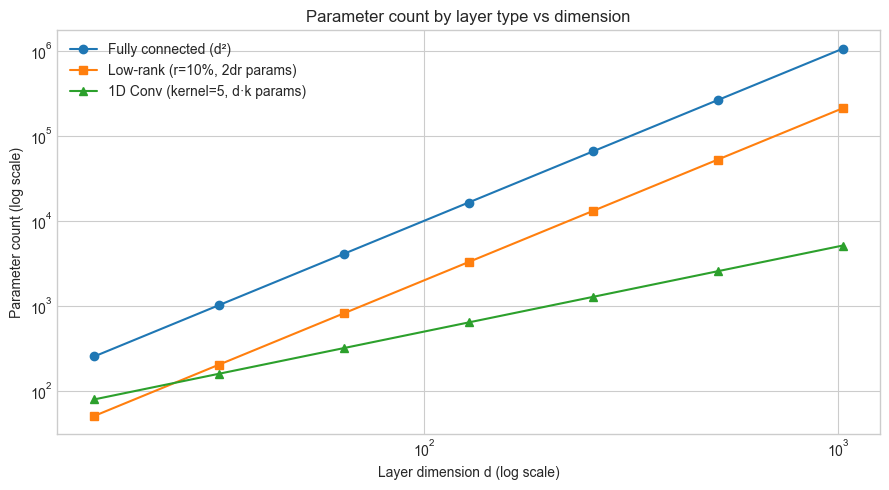

At d=512:
  Fully connected: 262,144 params
  Low-rank (r=51): 52,224 params (19.9% of FC)
  1D Conv (k=5):  2,560 params (0.98% of FC)


In [2]:
# --- Visualization: Parameter count and cost of layer variants ---
# Compare: fully connected, low-rank factored, and convolutional (1D)
# across different layer sizes.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

dims = np.array([16, 32, 64, 128, 256, 512, 1024])
RANK_FRAC = 0.1   # low-rank: keep 10% of dimensions
KERNEL_SIZE = 5   # 1D conv kernel width

# Parameter counts
fc_params    = dims * dims                                  # full weight matrix
lowrank_params = dims * (dims * RANK_FRAC) * 2             # A @ B where A:(d×r), B:(r×d)
conv_params  = dims * KERNEL_SIZE                           # each of d filters has kernel_size params

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(dims, fc_params,      'o-', label='Fully connected (d²)')
ax.loglog(dims, lowrank_params, 's-', label=f'Low-rank (r={RANK_FRAC:.0%}, 2dr params)')
ax.loglog(dims, conv_params,    '^-', label=f'1D Conv (kernel={KERNEL_SIZE}, d·k params)')
ax.set_xlabel('Layer dimension d (log scale)')
ax.set_ylabel('Parameter count (log scale)')
ax.set_title('Parameter count by layer type vs dimension')
ax.legend()
plt.tight_layout()
plt.show()

# Print at d=512
d = 512
r = int(d * RANK_FRAC)
print(f"At d={d}:")
print(f"  Fully connected: {d*d:,} params")
print(f"  Low-rank (r={r}): {2*d*r:,} params ({2*d*r/(d*d)*100:.1f}% of FC)")
print(f"  1D Conv (k={KERNEL_SIZE}):  {d*KERNEL_SIZE:,} params ({d*KERNEL_SIZE/(d*d)*100:.2f}% of FC)")

---

## 4. Mathematical Formulation

### Batched forward pass

Input batch: X ∈ R^{n_in × B} (n_in features, B samples as columns)

```
Z = W X + b·1ᵀ     where  W ∈ R^{n_out × n_in},  b ∈ R^{n_out},  1ᵀ ∈ R^{1×B}
```

The `b·1ᵀ` term broadcasts the bias across all B columns. In numpy: `W @ X + b[:, None]`.

### Batched gradient computation

With batch size B, the gradients become averaged sums:

```
∂L/∂W = (1/B) · Δ · Xᵀ    where  Δ ∈ R^{n_out × B} is the upstream gradient matrix
∂L/∂b = (1/B) · Δ · 1      (sum over batch, then divide)
∂L/∂X = Wᵀ · Δ             (gradient passed to previous layer)
```

All three are matrix multiplications or reductions — no loops required.

### Low-rank factored layers

Replace W ∈ R^{m×n} (rank up to min(m,n)) with:

```
W ≈ A B    where  A ∈ R^{m×r},  B ∈ R^{r×n},  r ≪ min(m,n)
```

Forward: `z = A(Bx)` — first project to r-dim, then lift to m-dim. Parameters: r(m+n) instead of mn. This is exactly the truncated SVD factorization from ch173, but learned end-to-end.

This idea reappears in **LoRA** (Low-Rank Adaptation): when fine-tuning a pretrained model, freeze the original W and add a low-rank residual ΔW = AB. Train only A and B.

### Scaled dot-product attention (the linear algebra view)

Given input X ∈ R^{d×T} (d features, T tokens), compute:

```
Q = W_Q X,   K = W_K X,   V = W_V X         (three linear layers)

A = softmax( Qᵀ K / √d_k )                  (T×T attention weight matrix)

output = V · Aᵀ                              (weighted sum of values)
```

The key observation: `output = V · Aᵀ` is a matrix-matrix multiplication where A is a *data-dependent* matrix with non-negative entries summing to 1 per column. Each output token is a convex combination of all value vectors — a projection (ch168) whose coefficients are learned from the query-key similarity.

---

## 5. Python Implementation

In [3]:
# --- Implementation: Fully connected layer with batched forward/backward ---
# Complete, from-scratch implementation matching the mathematical formulation.

import numpy as np

class Dense:
    """
    Fully connected (dense) layer: Z = WX + b.
    Supports batched inputs (X shape: n_in × batch_size).
    
    Args:
        n_in:  number of input features
        n_out: number of output features
    """
    def __init__(self, n_in, n_out):
        scale = np.sqrt(2.0 / (n_in + n_out))  # Xavier init
        self.W = np.random.randn(n_out, n_in) * scale  # (n_out, n_in)
        self.b = np.zeros(n_out)                        # (n_out,)

    def forward(self, X):
        """
        Forward pass.
        Args:
            X: shape (n_in,) for single sample, or (n_in, B) for batch
        Returns:
            Z: shape (n_out,) or (n_out, B)
        """
        self._X = X  # cache for backward
        if X.ndim == 1:
            return self.W @ X + self.b
        return self.W @ X + self.b[:, None]  # broadcast bias over batch

    def backward(self, dZ):
        """
        Backward pass.
        Args:
            dZ: upstream gradient, same shape as forward output
        Returns:
            dX: gradient w.r.t. input
        Side effects:
            Sets self.dW and self.db for gradient descent step.
        """
        X = self._X
        B = X.shape[1] if X.ndim == 2 else 1

        if X.ndim == 1:
            self.dW = np.outer(dZ, X) / B
            self.db = dZ / B
        else:
            self.dW = (dZ @ X.T) / B
            self.db = dZ.sum(axis=1) / B

        return self.W.T @ dZ

    def step(self, lr):
        """Apply one gradient descent update."""
        self.W -= lr * self.dW
        self.b -= lr * self.db


class LowRankDense:
    """
    Factored low-rank layer: Z = A(BX).
    Equivalent to a dense layer whose weight matrix has rank ≤ r.
    
    Args:
        n_in:  input dimension
        n_out: output dimension
        rank:  bottleneck rank r (r ≪ min(n_in, n_out))
    """
    def __init__(self, n_in, n_out, rank):
        scale_B = np.sqrt(2.0 / (n_in + rank))
        scale_A = np.sqrt(2.0 / (rank + n_out))
        self.B = np.random.randn(rank, n_in) * scale_B    # (r, n_in)
        self.A = np.random.randn(n_out, rank) * scale_A   # (n_out, r)
        self.b = np.zeros(n_out)

    def forward(self, X):
        self._X = X
        self._H = self.B @ X   # bottleneck activations, (r,) or (r, B)
        if X.ndim == 1:
            return self.A @ self._H + self.b
        return self.A @ self._H + self.b[:, None]

    def effective_weight_matrix(self):
        """Recover the full (n_out × n_in) weight matrix this layer represents."""
        return self.A @ self.B

    @property
    def n_params(self):
        r, n_in = self.B.shape
        n_out, _ = self.A.shape
        return r * n_in + n_out * r + n_out


# --- Verify equivalence and compare parameter counts ---
np.random.seed(1)
N_IN, N_OUT, RANK, BATCH = 64, 32, 8, 16

dense = Dense(N_IN, N_OUT)
lowrank = LowRankDense(N_IN, N_OUT, RANK)

X_batch = np.random.randn(N_IN, BATCH)

Z_dense   = dense.forward(X_batch)
Z_lowrank = lowrank.forward(X_batch)

print(f"Dense output shape:   {Z_dense.shape}")
print(f"LowRank output shape: {Z_lowrank.shape}")
print()
print(f"Dense params:    {N_OUT * N_IN + N_OUT:,}")
print(f"LowRank params:  {lowrank.n_params:,}  (rank={RANK}, {lowrank.n_params/(N_OUT*N_IN+N_OUT)*100:.1f}% of dense)")
print(f"Effective rank of LowRank W: {np.linalg.matrix_rank(lowrank.effective_weight_matrix())}")

Dense output shape:   (32, 16)
LowRank output shape: (32, 16)

Dense params:    2,080
LowRank params:  800  (rank=8, 38.5% of dense)
Effective rank of LowRank W: 8


In [4]:
# --- Implementation: Scaled dot-product attention (linear algebra core) ---
# No masking, no multi-head — just the essential matrix operations.

import numpy as np

def softmax(x, axis=-1):
    """
    Numerically stable softmax along specified axis.
    Subtracts max for numerical stability (ch036 — Numerical Stability).
    """
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    """
    Compute attention output.
    
    Args:
        Q: queries, shape (d_k, T)
        K: keys,    shape (d_k, T)
        V: values,  shape (d_v, T)
    Returns:
        output: shape (d_v, T)
        A:      attention weight matrix, shape (T, T)
    """
    d_k = Q.shape[0]

    # Similarity scores: each query attends to each key
    # scores[i,j] = Q[:,i] · K[:,j] / sqrt(d_k)
    scores = (Q.T @ K) / np.sqrt(d_k)   # shape (T, T)

    # Normalize rows → attention weights (sum to 1 per query)
    A = softmax(scores, axis=1)           # shape (T, T)

    # Weighted sum of values: each output is a convex combination
    output = V @ A.T                      # shape (d_v, T)

    return output, A


# --- Example: 4 tokens, d_k = d_v = 8 ---
np.random.seed(42)
T = 4    # sequence length
D = 8    # key/query/value dimension

# Projection weight matrices (the "linear layers" in attention)
W_Q = np.random.randn(D, D) * 0.1
W_K = np.random.randn(D, D) * 0.1
W_V = np.random.randn(D, D) * 0.1

# Input: 4 token embeddings
X_seq = np.random.randn(D, T)

Q = W_Q @ X_seq
K = W_K @ X_seq
V = W_V @ X_seq

out, A_weights = scaled_dot_product_attention(Q, K, V)

print(f"Input sequence shape: {X_seq.shape}")
print(f"Attention output shape: {out.shape}")
print(f"Attention weight matrix A (rows should sum to 1):")
print(A_weights.round(3))
print(f"Row sums: {A_weights.sum(axis=1).round(6)}")
print()
print("Interpretation: A[i,j] = how much token i attends to token j")
print("Output token i = weighted sum of all value vectors, weights given by row i of A")

Input sequence shape: (8, 4)
Attention output shape: (8, 4)
Attention weight matrix A (rows should sum to 1):
[[0.238 0.242 0.273 0.247]
 [0.271 0.242 0.226 0.261]
 [0.248 0.25  0.251 0.252]
 [0.287 0.235 0.241 0.237]]
Row sums: [1. 1. 1. 1.]

Interpretation: A[i,j] = how much token i attends to token j
Output token i = weighted sum of all value vectors, weights given by row i of A


---

## 6. Experiments

C:\Users\user\AppData\Local\Temp\ipykernel_17612\2441826168.py:58: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


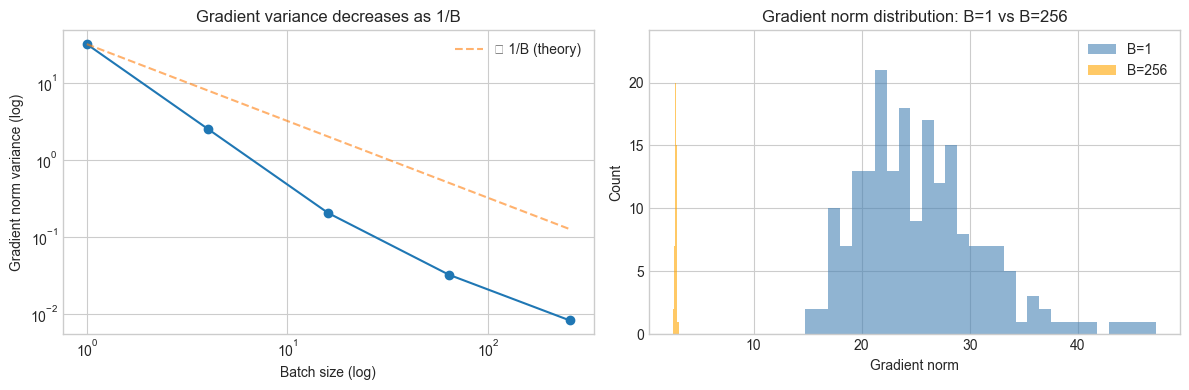

In [5]:
# --- Experiment 1: Batch size and gradient variance ---
# Hypothesis: Larger batch sizes produce lower-variance gradient estimates.
# This is a statistical effect: each gradient is an average of B samples.
# Try changing: BATCH_SIZES to observe the variance scaling

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(0)
N_IN, N_OUT = 32, 16
N_ESTIMATES = 200   # number of gradient samples per batch size
BATCH_SIZES = [1, 4, 16, 64, 256]   # <-- Try adding more values

W = np.random.randn(N_OUT, N_IN) * 0.1
true_grad_direction = np.random.randn(N_OUT, N_IN)  # "true" gradient direction
true_grad_direction /= np.linalg.norm(true_grad_direction)

variances = []
for B in BATCH_SIZES:
    grad_norms = []
    for _ in range(N_ESTIMATES):
        X = np.random.randn(N_IN, B)
        y = np.random.randn(N_OUT, B)
        Z = W @ X
        dZ = (Z - y) / B
        dW = dZ @ X.T
        grad_norms.append(np.linalg.norm(dW))
    variances.append(np.var(grad_norms))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(BATCH_SIZES, variances, 'o-')
# Theoretical: variance ∝ 1/B
B_arr = np.array(BATCH_SIZES, dtype=float)
axes[0].loglog(BATCH_SIZES, variances[0] * B_arr[0] / B_arr, '--', alpha=0.6, label='∝ 1/B (theory)')
axes[0].set_xlabel('Batch size (log)')
axes[0].set_ylabel('Gradient norm variance (log)')
axes[0].set_title('Gradient variance decreases as 1/B')
axes[0].legend()

# Distribution at two extremes
for B, color in [(1, 'steelblue'), (256, 'orange')]:
    norms = []
    for _ in range(N_ESTIMATES):
        X = np.random.randn(N_IN, B)
        y = np.random.randn(N_OUT, B)
        dW = ((W @ X - y) / B) @ X.T
        norms.append(np.linalg.norm(dW))
    axes[1].hist(norms, bins=30, alpha=0.6, color=color, label=f'B={B}')

axes[1].set_xlabel('Gradient norm')
axes[1].set_ylabel('Count')
axes[1].set_title('Gradient norm distribution: B=1 vs B=256')
axes[1].legend()

plt.tight_layout()
plt.show()

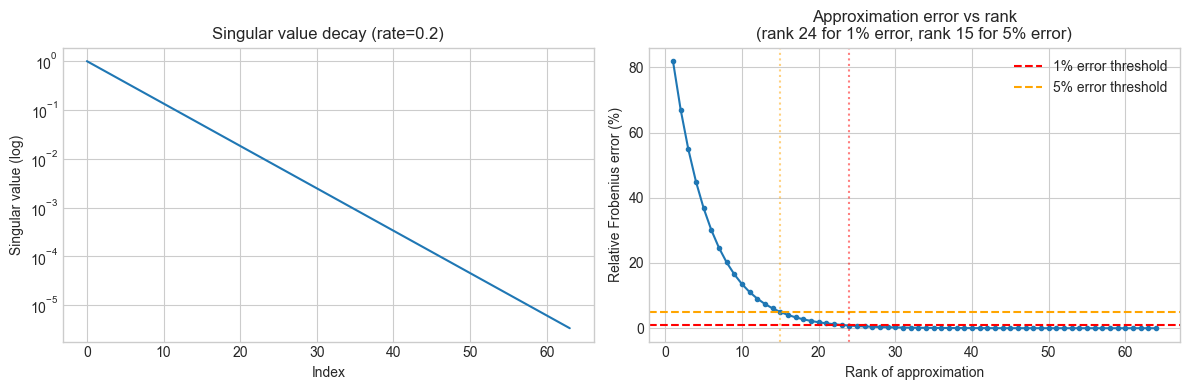

Full matrix: 4,096 params
Rank-24 approx: 3,072 params (25.0% reduction)
Reconstruction error at rank 24: 0.82%


In [6]:
# --- Experiment 2: Low-rank approximation quality vs rank ---
# Hypothesis: Approximating a learned weight matrix with a low-rank
# factorization preserves most of the computation if singular values decay fast.
# Try changing: DECAY_RATE to control how fast singular values fall off

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(3)
DIM = 64
DECAY_RATE = 0.2   # <-- Try: 0.05 (fast decay), 0.5 (slow decay), 1.0 (flat)

# Construct a matrix with known singular value decay
U, _ = np.linalg.qr(np.random.randn(DIM, DIM))
Vt, _ = np.linalg.qr(np.random.randn(DIM, DIM))
Vt = Vt.T
singular_values = np.exp(-DECAY_RATE * np.arange(DIM))
W = U @ np.diag(singular_values) @ Vt

# Low-rank approximations at various ranks
ranks = np.arange(1, DIM + 1)
rel_errors = []
for r in ranks:
    # Truncated SVD approximation (ch173)
    W_approx = U[:, :r] @ np.diag(singular_values[:r]) @ Vt[:r, :]
    error = np.linalg.norm(W - W_approx, 'fro') / np.linalg.norm(W, 'fro')
    rel_errors.append(error)

# Find rank needed for 99% and 95% accuracy
rel_errors = np.array(rel_errors)
rank_99 = np.searchsorted(1 - rel_errors, 0.99) + 1
rank_95 = np.searchsorted(1 - rel_errors, 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(np.arange(DIM), singular_values)
axes[0].set_xlabel('Index'); axes[0].set_ylabel('Singular value (log)')
axes[0].set_title(f'Singular value decay (rate={DECAY_RATE})')

axes[1].plot(ranks, rel_errors * 100, 'o-', markersize=3)
axes[1].axhline(1, color='red', linestyle='--', label='1% error threshold')
axes[1].axhline(5, color='orange', linestyle='--', label='5% error threshold')
axes[1].axvline(rank_99, color='red', alpha=0.5, linestyle=':')
axes[1].axvline(rank_95, color='orange', alpha=0.5, linestyle=':')
axes[1].set_xlabel('Rank of approximation')
axes[1].set_ylabel('Relative Frobenius error (%)')
axes[1].set_title(f'Approximation error vs rank\n(rank {rank_99} for 1% error, rank {rank_95} for 5% error)')
axes[1].legend()

plt.tight_layout()
plt.show()

param_reduction = 1 - (2 * DIM * rank_99) / (DIM * DIM)
print(f"Full matrix: {DIM*DIM:,} params")
print(f"Rank-{rank_99} approx: {2*DIM*rank_99:,} params ({param_reduction*100:.1f}% reduction)")
print(f"Reconstruction error at rank {rank_99}: {rel_errors[rank_99-1]*100:.2f}%")

---

## 7. Exercises

**Easy 1.** A fully connected layer maps from 784 dimensions to 256 dimensions. How many parameters does it have (include bias)? If you process a batch of 32 inputs simultaneously, what is the shape of the output matrix? *(Expected: 784×256 + 256 = 200,960 params; output shape: 256×32)*

**Easy 2.** Verify numerically that for a linear layer with no bias, the gradient `∂L/∂W` computed for a batch of B samples equals the average of the B individual single-sample gradients. Construct a small example (n_in=4, n_out=3, B=8) and compare. *(Expected: exact equality)*

**Medium 1.** Implement a LoRA-style adapter: given a frozen weight matrix `W₀` (shape m×n, fixed), and learnable low-rank matrices `A` (m×r) and `B` (r×n) initialized to zero, show that the effective weight at initialization is exactly `W₀`, and that after one gradient step, `W₀ + AB` differs from `W₀` only in the r-dimensional subspace spanned by A and B. *(Hint: initialize B=0 so AB=0 initially; verify with np.allclose)*

**Medium 2.** Implement a 1D convolutional layer as a matrix multiply: construct the circulant-like Toeplitz weight matrix for a kernel of size k and input of length n, and show that `W_toeplitz @ x` produces the same result as `np.convolve(x, kernel, mode='same')`. *(Hint: the Toeplitz matrix has the kernel entries shifted by one row each row)*

**Hard.** Show that the attention mechanism `output = V · softmax(QᵀK/√d_k)ᵀ` can be written as `output = V · Aᵀ` where A is a doubly-constrained matrix (rows sum to 1, all entries ≥ 0). Then prove that if Q = K (self-attention with identical queries and keys), the diagonal entries of A are always the largest in their row when d_k is small — i.e., each token attends most strongly to itself. Under what conditions does this break down? *(Challenge: connect to the temperature effect of the 1/√d_k scaling)*

---

## 8. Mini Project — Train a Two-Layer Network from Scratch on a Classification Task

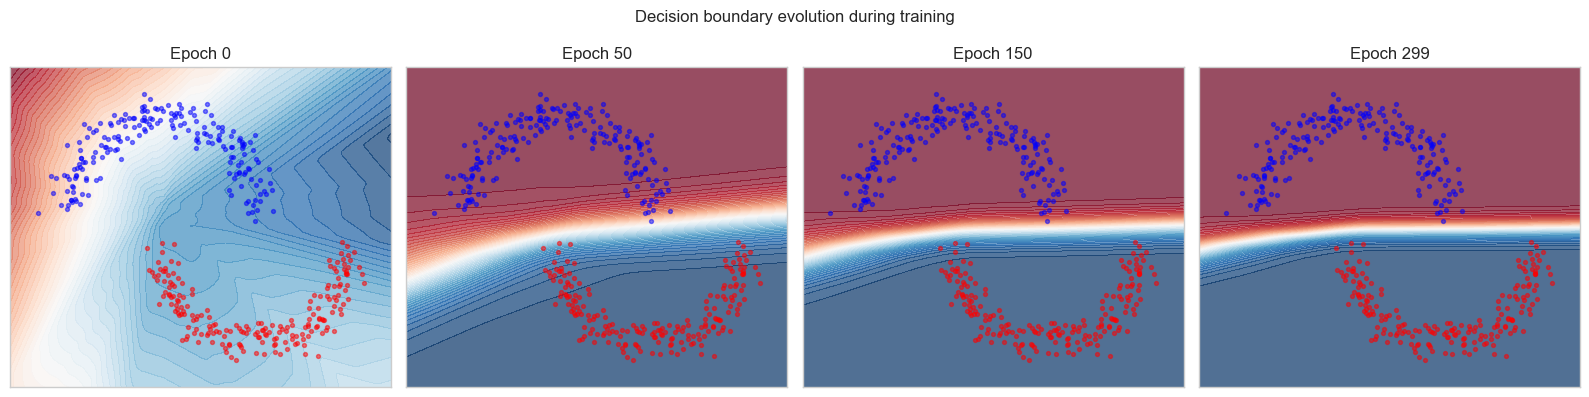

Final training accuracy: 100.0%


In [7]:
# --- Mini Project: Two-layer classifier on synthetic 2D data ---
# Problem: Classify points in R² from two interleaved half-moon distributions.
#          Train with mini-batch SGD, plot decision boundary over time.
# Dataset: Generated from np.random.randn + offsets
# Task:    Complete the training loop and visualize the decision boundary.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(7)

# --- Generate two-class dataset (concentric ring segments) ---
def make_moons(n=300, noise=0.1):
    n_half = n // 2
    theta1 = np.linspace(0, np.pi, n_half)
    theta2 = np.linspace(np.pi, 2*np.pi, n_half)
    X1 = np.column_stack([np.cos(theta1), np.sin(theta1)])
    X2 = np.column_stack([np.cos(theta2) + 1, np.sin(theta2) - 0.5])
    X = np.vstack([X1, X2]) + np.random.randn(n, 2) * noise
    y = np.array([0]*n_half + [1]*n_half)
    return X.T, y  # (2, N), (N,)

X_all, y_all = make_moons(n=400, noise=0.12)

# --- Network: 2 → 32 → 32 → 1 ---
# Layer dims
L1_IN, L1_OUT = 2, 32
L2_IN, L2_OUT = 32, 32
L3_IN, L3_OUT = 32, 1

xavier = lambda i, o: np.sqrt(2.0 / (i + o))

W1 = np.random.randn(L1_OUT, L1_IN) * xavier(L1_IN, L1_OUT)
b1 = np.zeros((L1_OUT, 1))
W2 = np.random.randn(L2_OUT, L2_IN) * xavier(L2_IN, L2_OUT)
b2 = np.zeros((L2_OUT, 1))
W3 = np.random.randn(L3_OUT, L3_IN) * xavier(L3_IN, L3_OUT)
b3 = np.zeros((L3_OUT, 1))

def relu(z): return np.maximum(0, z)
def relu_d(z): return (z > 0).astype(float)
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -50, 50)))

def forward(X):
    z1 = W1 @ X + b1;  a1 = relu(z1)
    z2 = W2 @ a1 + b2; a2 = relu(z2)
    z3 = W3 @ a2 + b3; a3 = sigmoid(z3)  # probability output
    return z1, a1, z2, a2, z3, a3

def bce_loss(p, y):
    """Binary cross-entropy loss."""
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

# --- Training ---
LR = 0.05
N_EPOCHS = 300
BATCH_SIZE = 64
N = X_all.shape[1]

loss_history = []
snapshot_epochs = [0, 50, 150, 299]
snapshots = {}

for epoch in range(N_EPOCHS):
    # Shuffle
    idx = np.random.permutation(N)
    X_shuf, y_shuf = X_all[:, idx], y_all[idx]

    epoch_loss = 0
    for start in range(0, N, BATCH_SIZE):
        Xb = X_shuf[:, start:start+BATCH_SIZE]
        yb = y_shuf[start:start+BATCH_SIZE]
        B = Xb.shape[1]

        z1, a1, z2, a2, z3, a3 = forward(Xb)
        loss = bce_loss(a3, yb)
        epoch_loss += loss

        # Backward
        d3 = (a3 - yb) / B                            # (1, B)
        dW3 = d3 @ a2.T; db3 = d3.sum(1, keepdims=True)
        d2 = (W3.T @ d3) * relu_d(z2)
        dW2 = d2 @ a1.T; db2 = d2.sum(1, keepdims=True)
        d1 = (W2.T @ d2) * relu_d(z1)
        dW1 = d1 @ Xb.T; db1 = d1.sum(1, keepdims=True)

        W1 -= LR * dW1; b1 -= LR * db1
        W2 -= LR * dW2; b2 -= LR * db2
        W3 -= LR * dW3; b3 -= LR * db3

    loss_history.append(epoch_loss)
    if epoch in snapshot_epochs:
        snapshots[epoch] = (W1.copy(), b1.copy(), W2.copy(), b2.copy(), W3.copy(), b3.copy())

# --- Visualization ---
def predict_grid(W1, b1, W2, b2, W3, b3, resolution=100):
    x_min, x_max = X_all[0].min()-0.3, X_all[0].max()+0.3
    y_min, y_max = X_all[1].min()-0.3, X_all[1].max()+0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.vstack([xx.ravel(), yy.ravel()])
    z1 = relu(W1 @ grid + b1)
    z2 = relu(W2 @ z1 + b2)
    p = sigmoid(W3 @ z2 + b3).reshape(resolution, resolution)
    return xx, yy, p

fig, axes = plt.subplots(1, len(snapshot_epochs), figsize=(16, 4))

for ax, ep in zip(axes, snapshot_epochs):
    ww1, bb1, ww2, bb2, ww3, bb3 = snapshots[ep]
    xx, yy, p = predict_grid(ww1, bb1, ww2, bb2, ww3, bb3)
    ax.contourf(xx, yy, p, levels=50, cmap='RdBu', alpha=0.7)
    ax.scatter(X_all[0, y_all==0], X_all[1, y_all==0], c='blue', s=8, alpha=0.5)
    ax.scatter(X_all[0, y_all==1], X_all[1, y_all==1], c='red', s=8, alpha=0.5)
    ax.set_title(f'Epoch {ep}')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Decision boundary evolution during training', fontsize=12)
plt.tight_layout()
plt.show()

# Final accuracy
_, _, _, _, _, probs = forward(X_all)
preds = (probs.ravel() > 0.5).astype(int)
acc = (preds == y_all).mean()
print(f"Final training accuracy: {acc*100:.1f}%")

---

## 9. Chapter Summary & Connections

**What this chapter covered:**
- Batching converts n_batch matrix-vector products into a single matrix-matrix multiply, enabling GPU parallelism and reducing per-sample computation cost.
- Gradient computation over a batch is the average of per-sample gradients — this directly reduces gradient variance by a factor of B, with variance scaling as 1/B.
- Low-rank factored layers (W ≈ AB) provide a principled way to trade parameter count for expressiveness, guided by the singular value spectrum of the weight matrix *(ch173 — SVD)*.
- Attention is a data-dependent linear combination of value vectors: `output = V · softmax(QᵀK/√d)ᵀ`. The Q, K, V projections are standard linear layers; the softmax produces the combination weights.
- Every architectural choice in deep learning (width, depth, weight sharing, factorization) has a direct linear algebra interpretation in terms of rank, conditioning, and spectral properties.

**Forward connections:**
- This chapter is the direct foundation for Part VII (Calculus). Chapter 212 (Gradient Descent) will revisit the mini-batch training loop and explain *why* the 1/B variance scaling matters for choosing learning rate schedules.
- The attention mechanism's softmax-weighted projection reappears implicitly in ch241 (Probability) when we study the softmax distribution as a categorical probability distribution over sequence positions.
- Low-rank factorization as a tool will return in ch273 (Dimensionality Reduction) where we analyze the information geometry of learned representations.

**Backward connection:**
- The batched gradient formula `∂L/∂W = (1/B) Δ Xᵀ` is a direct application of the matrix calculus derivative rules established in ch176, extended to the case where both Δ and X are matrices rather than vectors.

**Going deeper:** The LoRA paper (Hu et al., 2022) makes the low-rank factorization approach practical for fine-tuning large language models: by constraining weight updates to a rank-r subspace, full model quality is preserved with a 10,000× reduction in trainable parameters. The mathematical justification is the observation that learned weight matrices in large pretrained models have very fast singular value decay — most of their information is contained in the top singular directions.